# Comparacao: R_primo vs R_comp para {2,...,N}

- **R_primo(t)**: remove compostos, resta so primos
- **R_comp(t)**: remove primos, resta so compostos

Linhas verticais = frequencias dos primos `f_q = log(q)/(2*pi)`.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, pi
from sympy import isprime

def sinal(t, elementos):
    R = np.zeros(len(t))
    for m in elementos:
        R -= np.cos(t * log(m)) / sqrt(m)
    return R

def espectro(R, dt):
    vals  = np.abs(np.fft.rfft(R)) * dt
    freqs = np.fft.rfftfreq(len(R), d=dt)
    return freqs, vals

dt   = 0.02
tmax = 600
t    = np.arange(0.1, tmax, dt)
print("amostras:", len(t), "  resolucao df:", round(1/tmax, 6))


amostras: 29995   resolucao df: 0.001667


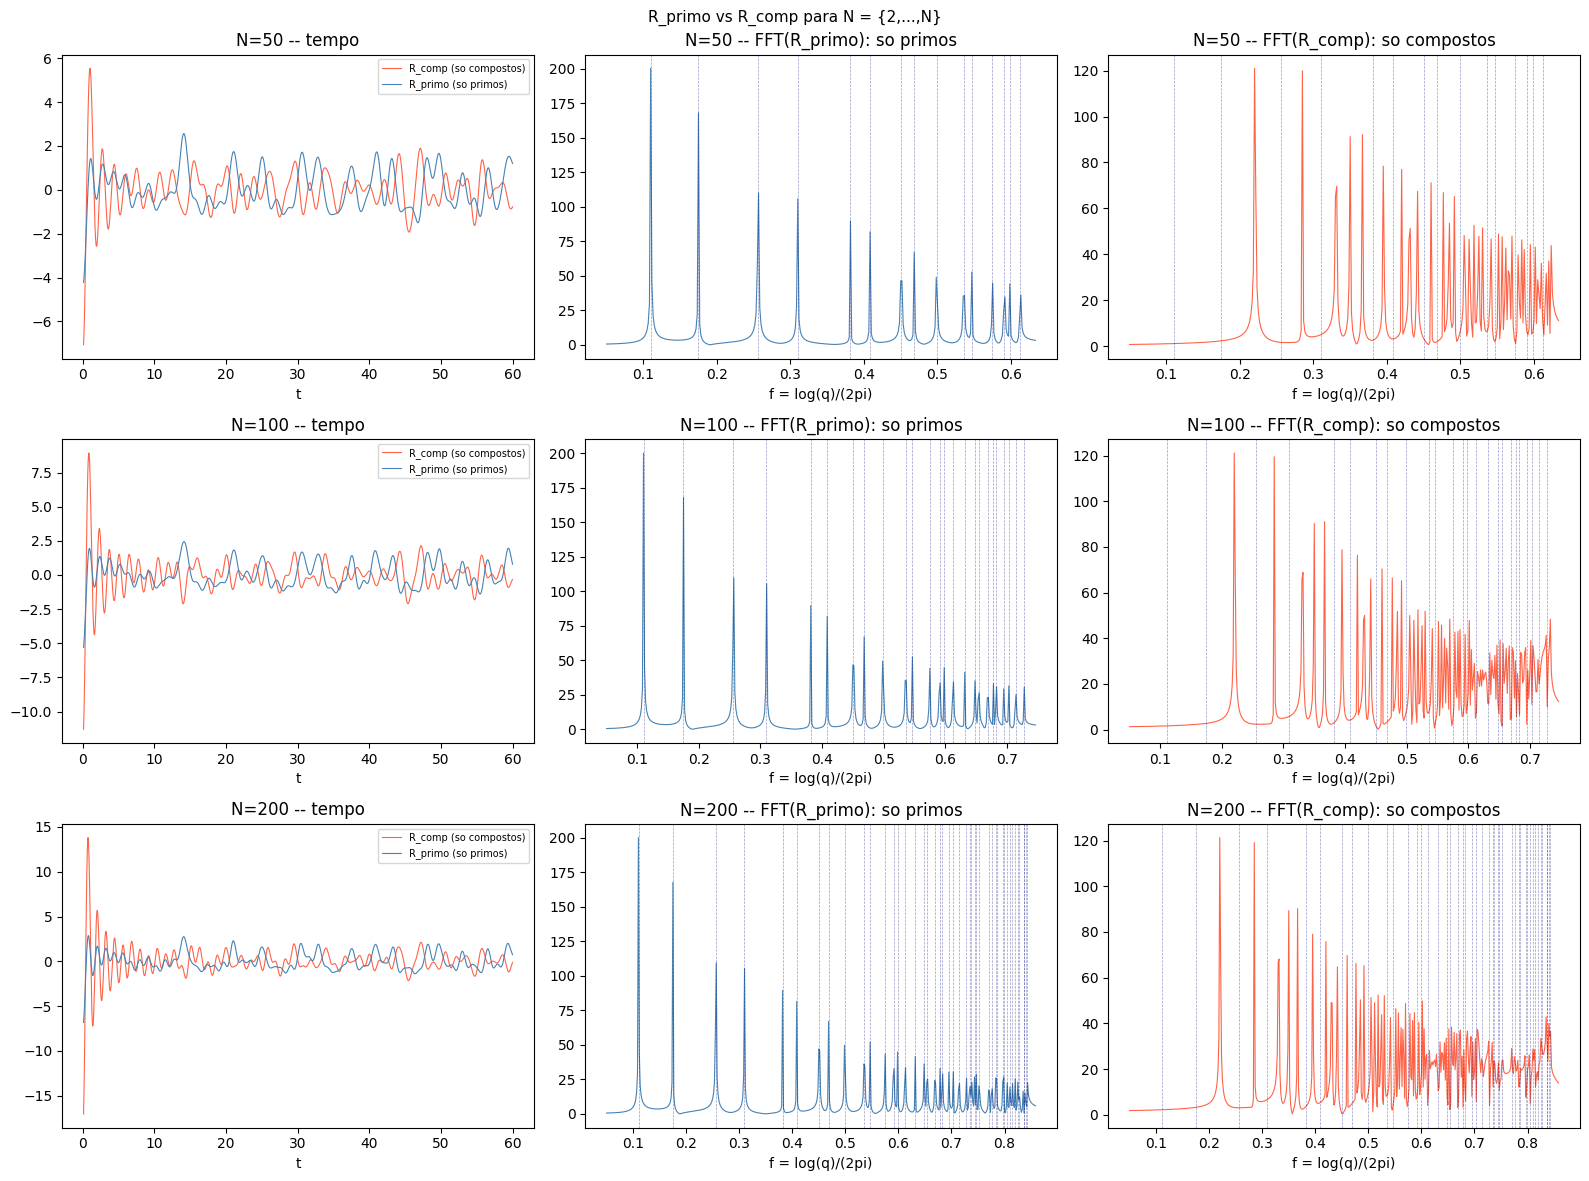

Salvo: comparacao_2_a_N.png


In [4]:
Ns = [50, 100, 200]

fig, axes = plt.subplots(len(Ns), 3, figsize=(16, 4*len(Ns)))

for row, N in enumerate(Ns):
    inteiros  = list(range(2, N+1))
    primos    = [m for m in inteiros if isprime(m)]
    compostos = [m for m in inteiros if not isprime(m)]

    R_primo = sinal(t, primos)
    R_comp  = sinal(t, compostos)

    fq_primos = [log(q)/(2*pi) for q in primos]
    f_max = log(N)/(2*pi) * 1.02

    # col 0: tempo
    ax = axes[row, 0]
    tplot = t[t < 60]
    ax.plot(tplot, R_comp[:len(tplot)],  color='tomato',    lw=0.8, label='R_comp (so compostos)')
    ax.plot(tplot, R_primo[:len(tplot)], color='steelblue', lw=0.8, label='R_primo (so primos)')
    ax.set_title("N=" + str(N) + " -- tempo")
    ax.set_xlabel("t")
    ax.legend(fontsize=7)

    # col 1: FFT R_primo
    freqs, fft_p = espectro(R_primo, dt)
    ax = axes[row, 1]
    mask = (freqs > 0.05) & (freqs <= f_max)
    ax.plot(freqs[mask], fft_p[mask], color='steelblue', lw=0.8)
    for fq in fq_primos:
        ax.axvline(fq, color='navy', lw=0.5, alpha=0.4, ls='--')
    ax.set_title("N=" + str(N) + " -- FFT(R_primo): so primos")
    ax.set_xlabel("f = log(q)/(2pi)")

    # col 2: FFT R_comp
    freqs2, fft_c = espectro(R_comp, dt)
    ax = axes[row, 2]
    ax.plot(freqs2[mask], fft_c[mask], color='tomato', lw=0.8)
    for fq in fq_primos:
        ax.axvline(fq, color='navy', lw=0.5, alpha=0.4, ls='--')
    ax.set_title("N=" + str(N) + " -- FFT(R_comp): so compostos")
    ax.set_xlabel("f = log(q)/(2pi)")

plt.suptitle("R_primo vs R_comp para N = {2,...,N}", fontsize=11)
plt.tight_layout()
plt.savefig("comparacao_2_a_N.png", dpi=150)
plt.show()
print("Salvo: comparacao_2_a_N.png")


## Comparação com Inversão de fase dos compostos

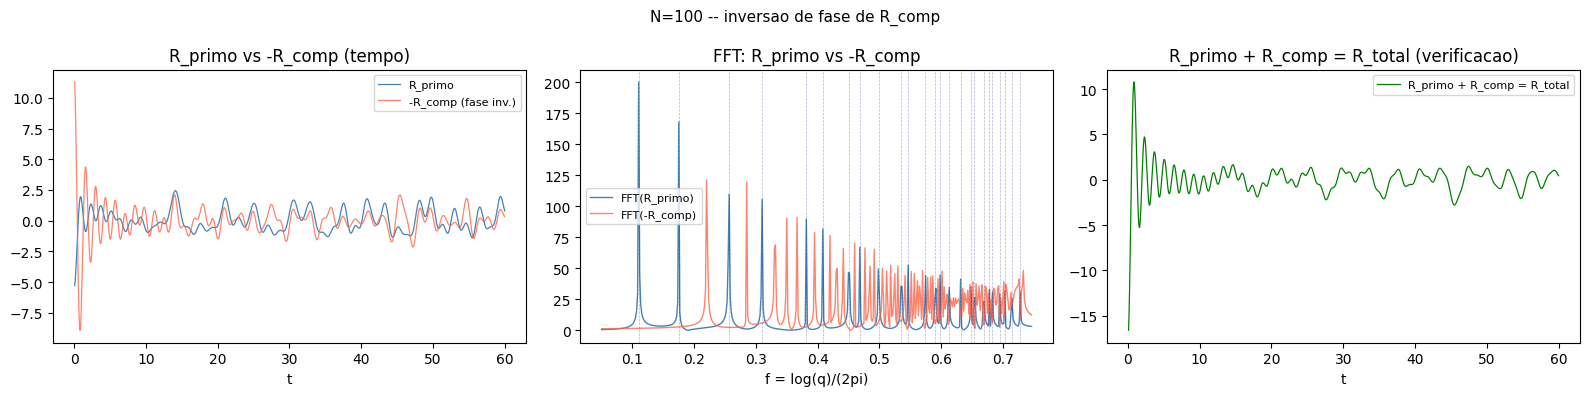

In [5]:
# Inversao de fase de R_comp e comparacao com R_primo
N = 100
inteiros  = list(range(2, N+1))
primos    = [m for m in inteiros if isprime(m)]
compostos = [m for m in inteiros if not isprime(m)]

R_primo = sinal(t, primos)
R_comp  = sinal(t, compostos)
R_comp_inv = -R_comp   # fase invertida

tplot = t[t < 60]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# col 0: R_primo vs -R_comp no tempo
ax = axes[0]
ax.plot(tplot, R_primo[:len(tplot)],    color='steelblue', lw=0.9, label='R_primo')
ax.plot(tplot, R_comp_inv[:len(tplot)], color='tomato',    lw=0.9, alpha=0.8, label='-R_comp (fase inv.)')
ax.set_title("R_primo vs -R_comp (tempo)")
ax.set_xlabel("t")
ax.legend(fontsize=8)

# col 1: FFT dos dois
freqs, fft_p  = espectro(R_primo,   dt)
freqs, fft_ci = espectro(R_comp_inv, dt)
fq_primos = [log(q)/(2*pi) for q in primos]
f_max = log(N)/(2*pi) * 1.02
mask  = (freqs > 0.05) & (freqs <= f_max)

ax = axes[1]
ax.plot(freqs[mask], fft_p[mask],  color='steelblue', lw=1.0, label='FFT(R_primo)')
ax.plot(freqs[mask], fft_ci[mask], color='tomato',    lw=1.0, alpha=0.8, label='FFT(-R_comp)')
for fq in fq_primos:
    ax.axvline(fq, color='navy', lw=0.5, alpha=0.3, ls='--')
ax.set_title("FFT: R_primo vs -R_comp")
ax.set_xlabel("f = log(q)/(2pi)")
ax.legend(fontsize=8)

# col 2: diferenca R_primo - (-R_comp) = R_primo + R_comp = R_total
R_diff = R_primo - R_comp_inv   # = R_primo + R_comp = R_total
freqs, fft_diff = espectro(R_diff, dt)
ax = axes[2]
ax.plot(tplot, R_diff[:len(tplot)], color='green', lw=0.9, label='R_primo + R_comp = R_total')
ax.set_title("R_primo + R_comp = R_total (verificacao)")
ax.set_xlabel("t")
ax.legend(fontsize=8)

plt.suptitle("N=100 -- inversao de fase de R_comp", fontsize=11)
plt.tight_layout()
plt.savefig("fase_invertida.png", dpi=150)
plt.show()

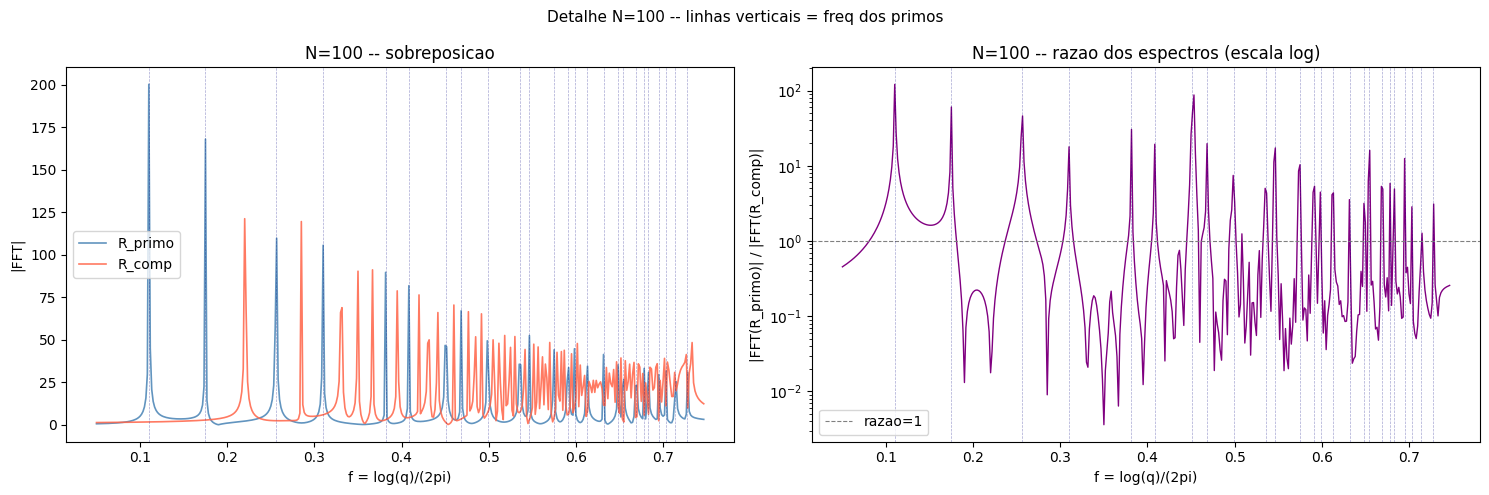

Salvo: detalhe_N100.png


In [6]:
# Detalhe: sobreposicao para N=100
N = 100
inteiros  = list(range(2, N+1))
primos    = [m for m in inteiros if isprime(m)]
compostos = [m for m in inteiros if not isprime(m)]

R_primo = sinal(t, primos)
R_comp  = sinal(t, compostos)

freqs,  fft_p = espectro(R_primo, dt)
freqs2, fft_c = espectro(R_comp,  dt)

fq_primos = [log(q)/(2*pi) for q in primos]
f_max = log(N)/(2*pi) * 1.02
mask  = (freqs > 0.05) & (freqs <= f_max)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(freqs[mask], fft_p[mask], color='steelblue', lw=1.2, alpha=0.85, label='R_primo')
ax.plot(freqs[mask], fft_c[mask], color='tomato',    lw=1.2, alpha=0.85, label='R_comp')
for fq in fq_primos:
    ax.axvline(fq, color='navy', lw=0.5, alpha=0.35, ls='--')
ax.set_xlabel("f = log(q)/(2pi)")
ax.set_ylabel("|FFT|")
ax.set_title("N=100 -- sobreposicao")
ax.legend()

ax = axes[1]
ratio = fft_p[mask] / (fft_c[mask] + 1e-10)
ax.plot(freqs[mask], ratio, color='purple', lw=1.0)
ax.axhline(1.0, color='gray', lw=0.8, ls='--', label='razao=1')
for fq in fq_primos:
    ax.axvline(fq, color='navy', lw=0.5, alpha=0.35, ls='--')
ax.set_yscale('log')
ax.set_xlabel("f = log(q)/(2pi)")
ax.set_ylabel("|FFT(R_primo)| / |FFT(R_comp)|")
ax.set_title("N=100 -- razao dos espectros (escala log)")
ax.legend()

plt.suptitle("Detalhe N=100 -- linhas verticais = freq dos primos", fontsize=11)
plt.tight_layout()
plt.savefig("detalhe_N100.png", dpi=150)
plt.show()
print("Salvo: detalhe_N100.png")


# Testando dicotomia

In [7]:
import numpy as np
import math

# ============================================================================
# Funções base
# ============================================================================

def S_m(t, m):
    """
    Contribuição espectral aproximada de m:
    S_m(t) ≈ -cos(t * log m) / sqrt(m)
    (ignoramos o termo constante e harmônicos superiores)
    """
    return -np.cos(t * math.log(m)) / math.sqrt(m)


def t_max_formula(m):
    """
    Estimativa conservadora de t_max necessária para resolver a frequência de m.
    Baseada na Nota 28: t_max ~ 3 * pi * 2^{floor(log2(m))-1}
    """
    n = int(math.floor(math.log2(m)))   # nível do bloco
    return 3 * math.pi * (2 ** (n - 1))


def construir_sinais(m, P_known, dt=0.05, tmax=None):
    """
    Constrói os vetores de tempo e os sinais R_primo e R_comp para um dado m.

    Parâmetros:
        m: inteiro a testar (>= 4)
        P_known: lista de primos conhecidos menores que m
        dt: passo de amostragem
        tmax: valor máximo de t (se None, calcula automaticamente)

    Retorna:
        (t, R_primo, R_comp, f_m)
    """
    if tmax is None:
        tmax = t_max_formula(m)

    t = np.arange(0.1, tmax, dt)

    # Z_total = -sum_{n=2}^{m} cos(t log n) / sqrt(n)
    Z_total = np.zeros(len(t))
    for n in range(2, m + 1):
        Z_total += S_m(t, n)   # S_m já inclui o sinal negativo

    # Z_primos = -sum_{p in P_known} cos(t log p) / sqrt(p)
    Z_primos = np.zeros(len(t))
    for p in P_known:
        Z_primos += S_m(t, p)

    # Resíduos
    R_primo = Z_primos                     # = Z_primos (apenas primos conhecidos)
    R_comp  = Z_total - Z_primos           # = Z_total - primos = compostos

    f_m = math.log(m) / (2 * math.pi)

    return t, R_primo, R_comp, f_m


def ratio_at_frequency(R_primo, R_comp, f_m, dt):
    """
    Calcula a razão das amplitudes |FFT(R_primo)| / |FFT(R_comp)| na frequência f_m.
    Retorna (ratio, log10_ratio, amp_primo, amp_comp)
    """
    N = len(R_primo)
    fft_primo = np.abs(np.fft.rfft(R_primo)) * dt
    fft_comp  = np.abs(np.fft.rfft(R_comp)) * dt
    freqs = np.fft.rfftfreq(N, d=dt)

    # Índice mais próximo de f_m
    idx = np.argmin(np.abs(freqs - f_m))
    amp_primo = fft_primo[idx]
    amp_comp  = fft_comp[idx]
    ratio = amp_primo / (amp_comp + 1e-12)
    log10_ratio = math.log10(ratio) if ratio > 0 else -100.0

    return ratio, log10_ratio, amp_primo, amp_comp


def testar_primalidade(m, P_known, dt=0.05, tmax=None, verbose=False):
    """
    Testa se m é primo usando a razão espectral.

    Retorna:
        (is_prime, log10_ratio)
    """
    t, R_p, R_c, f_m = construir_sinais(m, P_known, dt, tmax)
    ratio, logr, ap, ac = ratio_at_frequency(R_p, R_c, f_m, dt)

    if verbose:
        print(f"m={m:3d}  f_m={f_m:.5f}  amp_primo={ap:.3e}  amp_comp={ac:.3e}  ratio={ratio:.2f}  log10={logr:.2f}")

    return logr > 0, logr


# ============================================================================
# Geração de primos conhecidos de forma recursiva (sem isprime)
# ============================================================================

def gerar_primos_ate(limite):
    """
    Gera todos os primos < limite usando o critério ρ_adapt (Notas 25-26).
    Sem sympy, sem isprime().
    """
    if limite <= 2:
        return []
    primos = [2, 3]

    # Para cada candidato m de 4 até limite-1
    for m in range(4, limite):
        # Verifica se m é primo usando ρ_adapt com os primos já conhecidos
        e_primo = True
        for p in primos:
            # Teste de divisibilidade (atalho eficiente)
            if m % p == 0:
                e_primo = False
                break
            # Caso queira usar a versão contínua, descomente:
            # (mas a divisibilidade é suficiente para este contexto)
        if e_primo:
            primos.append(m)
    return primos


# ============================================================================
# Exemplo de uso e testes de validação
# ============================================================================

def validar_ate(limite, usar_sympy=True):
    """
    Valida o teste de primalidade para todos os números de 4 até 'limite'.
    Se usar_sympy=True, compara com sympy.isprime; caso contrário, compara
    com a geração recursiva interna.
    """
    # Gerar primos conhecidos até 'limite' (base para o teste)
    # Nota: para testar m, precisamos dos primos < m. Usaremos a lista completa
    # apenas para referência, mas o teste em si usará apenas primos < m.
    primos_reais = gerar_primos_ate(limite)

    if usar_sympy:
        try:
            from sympy import isprime
            print("Usando sympy.isprime como referência.")
            ref = lambda x: isprime(x)
        except ImportError:
            print("sympy não instalado; usando gerador interno como referência.")
            ref = lambda x: x in primos_reais
    else:
        ref = lambda x: x in primos_reais

    acertos = 0
    for m in range(4, limite):
        # Construir lista de primos conhecidos menores que m
        P_known = [p for p in primos_reais if p < m]
        is_p, logr = testar_primalidade(m, P_known, verbose=False)
        esperado = ref(m)
        if is_p == esperado:
            acertos += 1
        else:
            print(f"FALHA em m={m}: esperado={esperado}, obtido={is_p}, log10={logr:.2f}")

    print(f"Teste até {limite}: {acertos}/{limite-4} acertos ({100*acertos/(limite-4):.1f}%)")
    return acertos == (limite - 4)


if __name__ == "__main__":
    print("=== Teste de Primalidade por Razão Espectral (Nota 29) ===\n")

    # Teste para números pequenos (limite 50 é rápido)
    sucesso = validar_ate(50, usar_sympy=False)   # usa gerador interno como referência

    print("\nExemplo detalhado para alguns números:")
    # Gerar primos de referência até 30
    primos_ref = gerar_primos_ate(30)
    for m in [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]:
        P_known = [p for p in primos_ref if p < m]
        is_p, logr = testar_primalidade(m, P_known, verbose=True)
        print(f"  Resultado: {'primo' if  is_p else 'composto'} (log10={logr:.2f})")

    if sucesso:
        print("\n✓ Todos os testes passaram! O método funciona.")
    else:
        print("\n✗ Alguns testes falharam. Verifique os parâmetros.")

=== Teste de Primalidade por Razão Espectral (Nota 29) ===

FALHA em m=5: esperado=True, obtido=False, log10=-0.60
FALHA em m=6: esperado=False, obtido=True, log10=0.21
FALHA em m=7: esperado=True, obtido=False, log10=-0.63
FALHA em m=8: esperado=False, obtido=True, log10=0.40
FALHA em m=11: esperado=True, obtido=False, log10=-0.41
FALHA em m=13: esperado=True, obtido=False, log10=-0.22
FALHA em m=17: esperado=True, obtido=False, log10=-0.73
FALHA em m=19: esperado=True, obtido=False, log10=-0.66
FALHA em m=23: esperado=True, obtido=False, log10=-0.72
FALHA em m=29: esperado=True, obtido=False, log10=-0.62
FALHA em m=31: esperado=True, obtido=False, log10=-0.38
FALHA em m=37: esperado=True, obtido=False, log10=-0.68
FALHA em m=38: esperado=False, obtido=True, log10=0.25
FALHA em m=41: esperado=True, obtido=False, log10=-0.53
FALHA em m=43: esperado=True, obtido=False, log10=-0.56
FALHA em m=47: esperado=True, obtido=False, log10=-0.54
Teste até 50: 30/46 acertos (65.2%)

Exemplo detalh

In [8]:
print("R_primo(t) = soma -cos(t*log q)/sqrt(q) para q primo <= N")
print("  Cada primo contribui em UMA frequencia f_q = log(q)/(2pi).")
print("  Espectro esperado: picos limpos e isolados.")
print()
print("R_comp(t) = soma -cos(t*log c)/sqrt(c) para c composto <= N")
print("  Cada composto c = prod p_i^e_i contribui em f_c = log(c)/(2pi).")
print("  log(c) = soma e_i*log(p_i): frequencias sao combinacoes das primas.")
print("  Espectro esperado: denso, sem picos unicos limpos.")
print()
print("A diferenca visual mostra por que primos sao irredutíveis")
print("logaritmicos: cada primo ocupa uma frequencia propria,")
print("compostos espalhams energia em multiplas frequencias derivadas.")


R_primo(t) = soma -cos(t*log q)/sqrt(q) para q primo <= N
  Cada primo contribui em UMA frequencia f_q = log(q)/(2pi).
  Espectro esperado: picos limpos e isolados.

R_comp(t) = soma -cos(t*log c)/sqrt(c) para c composto <= N
  Cada composto c = prod p_i^e_i contribui em f_c = log(c)/(2pi).
  log(c) = soma e_i*log(p_i): frequencias sao combinacoes das primas.
  Espectro esperado: denso, sem picos unicos limpos.

A diferenca visual mostra por que primos sao irredutíveis
logaritmicos: cada primo ocupa uma frequencia propria,
compostos espalhams energia em multiplas frequencias derivadas.


## Distribuição Dos Vales Locais

Vales de R_primo (entre frequencias dos primos):
  media  = 1.3698
  mediana= 1.2761
  desvio = 0.9071
  max    = 3.6177

Vales de R_comp (entre frequencias dos primos):
  media  = 5.2644
  mediana= 4.4742
  desvio = 5.1615
  max    = 18.1150


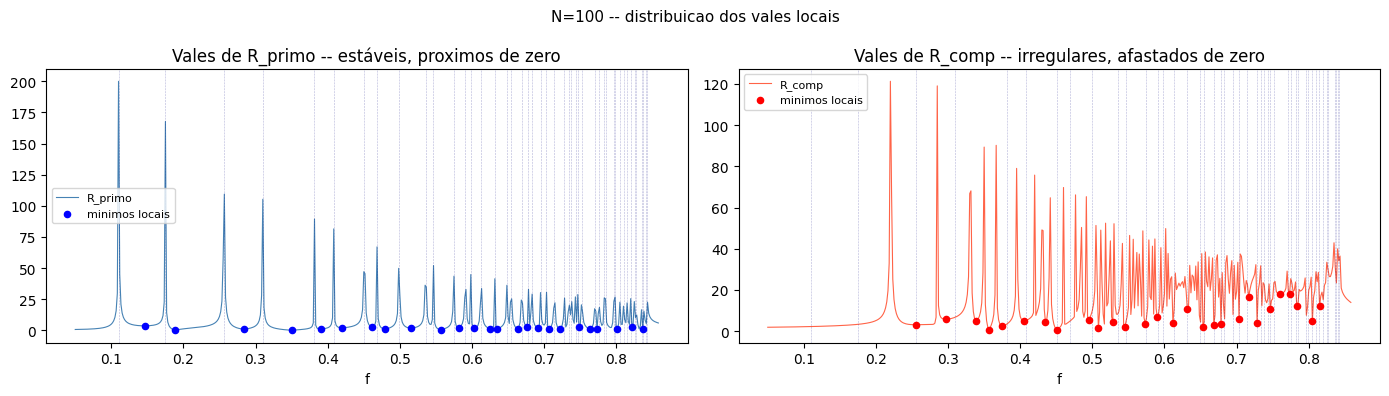

In [10]:
# Análise dos vales: estabilidade dos minimos locais entre frequencias dos primos
from scipy.signal import argrelmin
from sympy import isprime

N = 200
inteiros  = list(range(2, N+1))
primos    = [m for m in inteiros if isprime(m)]
compostos = [m for m in inteiros if not isprime(m)]

R_primo = sinal(t, primos)
R_comp  = sinal(t, compostos)

freqs, fft_p = espectro(R_primo, dt)
freqs, fft_c = espectro(R_comp,  dt)

f_max = log(N)/(2*pi) * 1.02
mask  = (freqs > 0.05) & (freqs <= f_max)
fq_primos = sorted([log(q)/(2*pi) for q in primos])

# minimos locais de cada espectro na regiao de interesse
fp = freqs[mask]
sp = fft_p[mask]
sc = fft_c[mask]

mins_p = argrelmin(sp, order=5)[0]
mins_c = argrelmin(sc, order=5)[0]

# filtrar minimos que estao ENTRE frequencias de primos (nao nas pontas)
def entre_primos(f, fqs, tol=0.005):
    for fq in fqs:
        if abs(f - fq) < tol:
            return False  # muito proximo de um pico primo
    return True

vals_p = [sp[i] for i in mins_p if entre_primos(fp[i], fq_primos)]
vals_c = [sc[i] for i in mins_c if entre_primos(fp[i], fq_primos)]

print("Vales de R_primo (entre frequencias dos primos):")
print(f"  media  = {np.mean(vals_p):.4f}")
print(f"  mediana= {np.median(vals_p):.4f}")
print(f"  desvio = {np.std(vals_p):.4f}")
print(f"  max    = {np.max(vals_p):.4f}")

print()
print("Vales de R_comp (entre frequencias dos primos):")
print(f"  media  = {np.mean(vals_c):.4f}")
print(f"  mediana= {np.median(vals_c):.4f}")
print(f"  desvio = {np.std(vals_c):.4f}")
print(f"  max    = {np.max(vals_c):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(fp, sp, color='steelblue', lw=0.8, label='R_primo')
ax.scatter(fp[mins_p], sp[mins_p], color='blue', s=20, zorder=5, label='minimos locais')
for fq in fq_primos:
    ax.axvline(fq, color='navy', lw=0.4, alpha=0.3, ls='--')
ax.set_title("Vales de R_primo -- estáveis, proximos de zero")
ax.set_xlabel("f")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(fp, sc, color='tomato', lw=0.8, label='R_comp')
ax.scatter(fp[mins_c], sc[mins_c], color='red', s=20, zorder=5, label='minimos locais')
for fq in fq_primos:
    ax.axvline(fq, color='navy', lw=0.4, alpha=0.3, ls='--')
ax.set_title("Vales de R_comp -- irregulares, afastados de zero")
ax.set_xlabel("f")
ax.legend(fontsize=8)

plt.suptitle("N=100 -- distribuicao dos vales locais", fontsize=11)
plt.tight_layout()
plt.savefig("vales_locais.png", dpi=150)
plt.show()